In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import re
from aquarel import load_theme
import numpy as np
theme = load_theme("minimal_light")
theme.apply()
theme.apply_transforms()
import matplotlib as mpl
mpl.rcParams['axes.spines.left'] = True
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.bottom'] = True
mpl.rcParams['axes.edgecolor'] = 'grey'
from scipy.stats import ks_2samp
import itertools
import pandas as pd
import matplotlib.patches as patches

<Figure size 640x480 with 0 Axes>

In [2]:
param_traversals = glob.glob('../../data/four-state_markov_model/snakemake_results/*/paramtraversal.csv')

num_replicates = 11
powers = [3,2,1,0.75,0.5,0.25]
pts = []
for i,pt_path in enumerate(param_traversals):
    match = re.search(r"synth_tree_(\d+)", pt_path)
    number = int(match.group(1))  # type: ignore
    pt = pd.read_csv(pt_path)
    pt = pt[pt['Threshold'].isin([0.01])]
    pt = pt[pt['Bonferroni'].isin(['fdr_by'])]
    pt['Power'] = [powers[number//num_replicates] for j in pt['Method']]
    pts.append(pt)


pt_concat = pd.concat(pts)
pt_concat.drop(columns = 'Accuracy', inplace=True)
SimPhyNI_df = pd.read_csv('../../data/four-state_markov_model/snakemake_results/SimPhyNI_performance.csv', index_col = 0)
SimPhyNI_df['Statistic'] = ['_log_odds_ratio_statistic' for i in SimPhyNI_df['Method']]
method_map = {
    'SimPhyNI' : 'simulate',
}
SimPhyNI_df['Method'] = SimPhyNI_df['Method'].map(method_map)
SimPhyNI_df['Threshold'] = [0.01 for i in SimPhyNI_df['Method']]
SimPhyNI_df['Bonferroni'] = ['fdr_by' for i in SimPhyNI_df['Method']]
x = SimPhyNI_df[pt_concat.columns]
y = pt_concat.loc[~((pt_concat['Method'].isin(SimPhyNI_df['Method'])) & (pt_concat['Threshold'] == 0.01) & (pt_concat['Bonferroni'] == 'fdr_by') & (pt_concat['Statistic'] == '_log_odds_ratio_statistic'))]
pt_concat = pd.concat([x,y])

pt_merge = pt_concat.groupby(['Method','Statistic','Power','Bonferroni']).mean()
pt_merge_std = pt_concat.groupby(['Method','Statistic','Power','Bonferroni']).std()
pt_merge.reset_index(inplace = True)
pt_merge_std.reset_index(inplace = True)
pt_merge['Method'] = ['_'.join(j.split('_')[1:]) + "_" + (i.split('_')[0] if i[0] != '_' else i.split('_')[1] +" "+ i.split('_')[2]) for i,j in zip(pt_merge['Statistic'],pt_merge['Method'])]
pt_merge_std['Method'] = ['_'.join(j.split('_')[1:]) + "_" + (i.split('_')[0] if i[0] != '_' else i.split('_')[1] +" "+ i.split('_')[2]) for i,j in zip(pt_merge_std['Statistic'],pt_merge_std['Method'])]

df = pt_merge
df_std = pt_merge_std

In [3]:
def plot_trav(pt_concat, metric, pow, ascending=True, highlight_sim_log_odds=True):
    """
    Plots a heatmap of travel metrics from a concatenated DataFrame.

    :param pt_concat: The DataFrame containing the data.
    :param metric: The column name for the values in the heatmap.
    :param pow: The value to filter the 'Power' column by.
    :param ascending: Boolean to determine the colormap (True for 'Blues', False for 'Blues_r').
    :param highlight_sim_log_odds: If True, draws a red box around the cell
                                   corresponding to Method='sim' and Statistic='log_odds_ratio'.
    """
    
    # Pivot the data
    df_filtered = pt_concat[pt_concat['Power'] == pow]
    piv = pd.pivot_table(df_filtered, index='Method', columns='Statistic', values=metric)
    
    # Store original labels before renaming to find the correct position
    original_index = list(piv.index)
    original_columns = list(piv.columns)

    # Rename index and columns as in the original function
    piv.index = ['sim' if i == 'simulate' else i[9:] for i in original_index]
    piv.columns = [i[1:-10] if i[0] == '_' else i[:-10] for i in original_columns]
    
    plt.figure(figsize=(4.5, 4.5))
    
    # Create heatmap and get the Axes object
    ax = sns.heatmap(piv, 
                     cmap='Blues' if ascending else 'Blues_r', 
                     annot=True, 
                     fmt=".3f", 
                     cbar=False, 
                     cbar_kws={'ticks': []}, 
                     square=True)

    # Draw the box if the boolean option is True
    if highlight_sim_log_odds:
        target_method = 'sim'
        target_statistic = 'log_odds_ratio'
        
        try:
            # Get the integer position (0-based index) of the target cell in the renamed pivot table
            y_pos = piv.index.get_loc(target_method)
            x_pos = piv.columns.get_loc(target_statistic)
            
            # Create the rectangle patch. For a heatmap cell at (row, col) = (y_pos, x_pos),
            # the bottom-left corner of the patch should be at coordinates (x_pos, y_pos).
            rect = patches.Rectangle((x_pos, y_pos), 1, 1, 
                                     linewidth=3, 
                                     edgecolor='red', 
                                     facecolor='none', 
                                     clip_on=False) # Keep the box visible even at edges
            
            # Add the patch to the axes
            ax.add_patch(rect)
            
        except KeyError as e:
            # Handle case where the expected Method or Statistic might not be present in the data
            print(f"Warning: Could not find the target label for highlighting: {e}")

    plt.ylabel('Simulation Method')
    plt.xlabel('Scoring Funtion')
    plt.title(metric.replace('_', ' '))
    plt.tight_layout()
    # plt.savefig('fig.svg', format='svg')
    plt.show()

def test_metric(stat_name,value):
    df_logodds = pt_concat[pt_concat["Statistic"] == stat_name].copy()
    all_ks = []
    for power in sorted(df_logodds["Power"].unique()):
        sub = df_logodds[df_logodds["Power"] == power]
        for m1, m2 in itertools.combinations(sub["Method"].unique(), 2):
            stat, pval = ks_2samp(sub.loc[sub["Method"]==m1,value],
                                sub.loc[sub["Method"]==m2,value])
            all_ks.append({"Power": power, "Method1": m1, "Method2": m2,
                        "KS_stat": stat, "pval": pval})
    ks_df = pd.DataFrame(all_ks)
    ks_df = ks_df[ks_df['Power'] == 1]
    return ks_df


def plot_ks(ks_df, metric_name, stat_col="KS_stat", pval_col="pval"):
    """
    Plot pairwise KS statistics as a heatmap, annotated with significance stars.
    Grey out diagonal tiles (self-comparisons).
    """
    # Get all methods
    methods = sorted(set(ks_df["Method1"]).union(ks_df["Method2"]))
    n = len(methods)

    # Initialize full symmetric matrices
    matrix_stat = pd.DataFrame(np.nan, index=methods, columns=methods)
    matrix_pval = pd.DataFrame(np.nan, index=methods, columns=methods)

    for _, row in ks_df.iterrows():
        m1, m2 = row["Method1"], row["Method2"]
        matrix_stat.loc[m1, m2] = row[stat_col]
        matrix_stat.loc[m2, m1] = row[stat_col]
        matrix_pval.loc[m1, m2] = row[pval_col]
        matrix_pval.loc[m2, m1] = row[pval_col]

    # Significance → stars
    def p_to_stars(p):
        if pd.isnull(p): return ""
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return "ns"

    star_annot = matrix_pval.map(p_to_stars)

    # Mask diagonal (to grey out)
    mask = np.eye(len(matrix_stat), dtype=bool)

    # Create custom colormap with greyed-out diagonal
    cmap = sns.color_palette("viridis", as_cmap=True)

    plt.figure(figsize=(4.5,4.5))
    ax = sns.heatmap(matrix_stat.astype(float), 
                     cmap=cmap, 
                     annot=star_annot, 
                     fmt="", 
                     square=True,
                     cbar_kws={"label": "KS statistic", 'shrink': 0.5},
                     linewidths=0,
                     vmin=0, vmax=1,
                     mask=mask)

    # Overlay grey diagonal tiles manually
    for i in range(n):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color="lightgrey", lw=0))

    plt.title(f"{metric_name.replace('_',' ')}")
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

   


In [ ]:
pt_concat.to_csv()

,Method,Statistic,Threshold,Bonferroni,Precision_Negative,Recall_Negative,F1_Negative,Precision_Positive,Recall_Positive,F1_Positive,AUC_ROC_Negative,PR_AUC_Negative,AUC_ROC_Positive,PR_AUC_Positive,FDR_Negative,FPR_Negative,FDR_Positive,FPR_Positive,Power
0,simulate,_log_odds_ratio_statistic,0.01,fdr_by,0.981567,0.710000,0.823985,0.996503,0.950000,0.972696,0.995875,0.965814,0.999970,0.999660,0.018433,0.001212,0.003497,0.000303,3.0
1,simulate,_log_odds_ratio_statistic,0.01,fdr_by,0.977376,0.720000,0.829175,0.985965,0.936667,0.960684,0.992824,0.947108,0.999583,0.995751,0.022624,0.001515,0.014035,0.001212,3.0
2,simulate,_log_odds_ratio_statistic,0.01,fdr_by,0.991228,0.753333,0.856061,0.981413,0.880000,0.927944,0.996356,0.969069,0.999471,0.993979,0.008772,0.000606,0.018587,0.001515,3.0
3,simulate,_log_odds_ratio_statistic,0.01,fdr_by,0.981982,0.726667,0.835249,0.989761,0.966667,0.978078,0.993289,0.954847,0.999863,0.998533,0.018018,0.001212,0.010239,0.000909,3.0
4,simulate,_log_odds_ratio_statistic,0.01,fdr_by,0.973684,0.740000,0.840909,0.989655,0.956667,0.972881,0.994289,0.956519,0.999912,0.999028,0.026316,0.001818,0.010345,0.000909,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,simulate_norm,z_statistic,0.01,fdr_by,1.000000,0.446667,0.617512,0.870968,0.090000,0.163142,0.987191,0.937889,0.984059,0.845896,0.000000,0.000000,0.129032,0.001212,1.0
148,simulate,count_statistic,0.01,fdr_by,0.512064,0.636667,0.567608,0.675862,0.326667,0.440449,0.902917,0.592521,0.924374,0.580440,0.487936,0.055152,0.324138,0.014242,1.0
154,simulate_nodist,count_statistic,0.01,fdr_by,0.303548,0.770000,0.435438,0.575342,0.420000,0.485549,0.872441,0.538297,0.916659,0.568235,0.696452,0.160606,0.424658,0.028182,1.0
160,simulate_ctmp,count_statistic,0.01,fdr_by,0.354978,0.546667,0.430446,0.562842,0.343333,0.426501,0.868594,0.490390,0.893876,0.514565,0.645022,0.090303,0.437158,0.024242,1.0


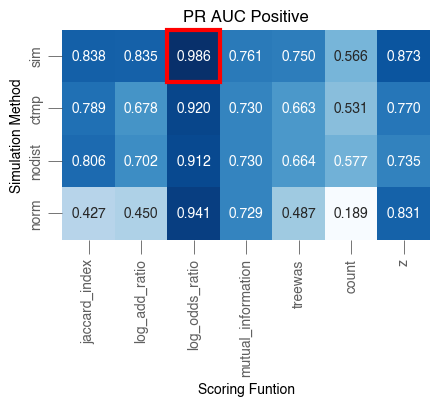

In [4]:
### Figure S2 (1/4)
plot_trav(pt_concat=pt_concat,metric=  "PR_AUC_Positive", pow = .75)

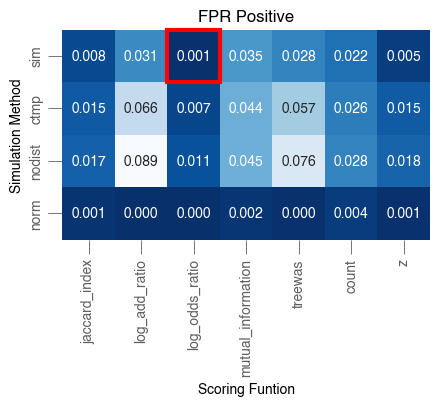

In [5]:
### Figure S2 (2/4)
plot_trav(pt_concat=pt_concat,metric=  "FPR_Positive", pow = .75, ascending=False)

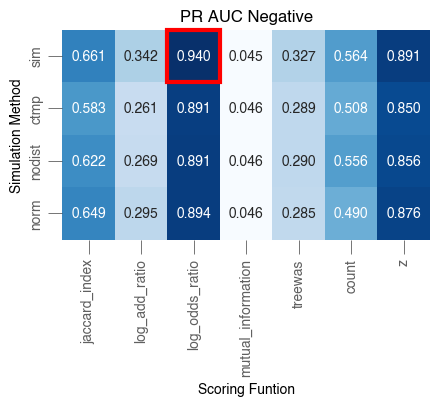

In [6]:
### Figure S2 (3/4)
plot_trav(pt_concat=pt_concat,metric=  "PR_AUC_Negative", pow = .75)

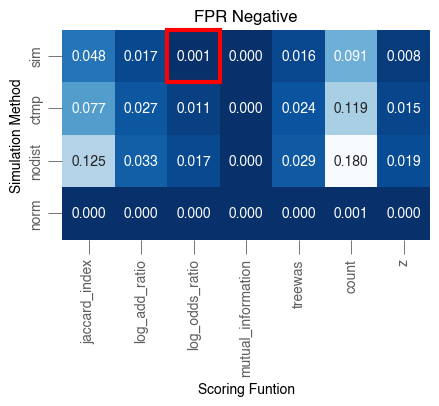

In [7]:
### Figure S2 (4/4)
plot_trav(pt_concat=pt_concat,metric=  "FPR_Negative", pow = .75, ascending=False)

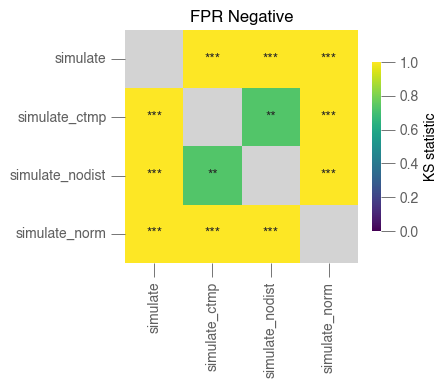

In [8]:
stat_name = "_log_odds_ratio_statistic"
value = 'FPR_Negative'
ks = test_metric(stat_name, value)
plot_ks(ks,value)

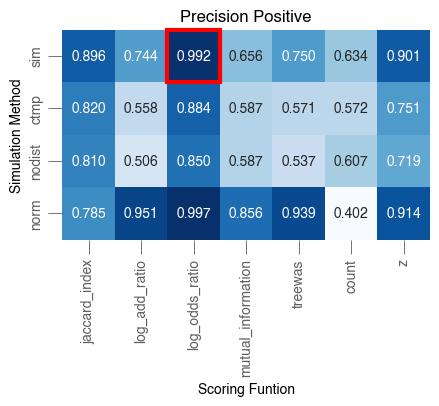

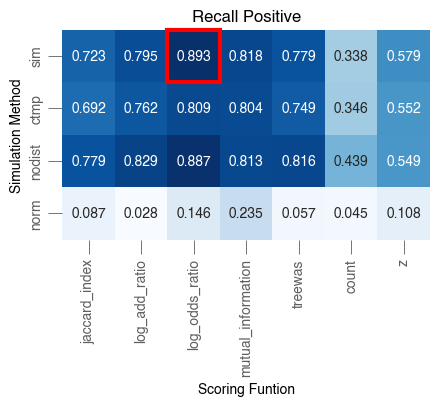

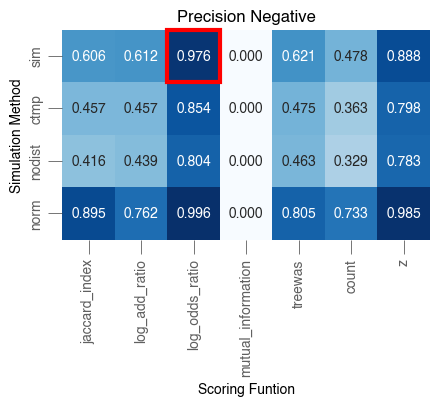

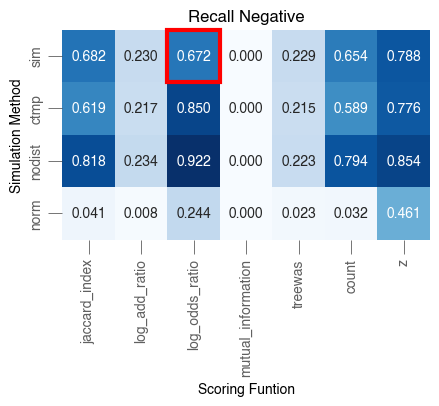

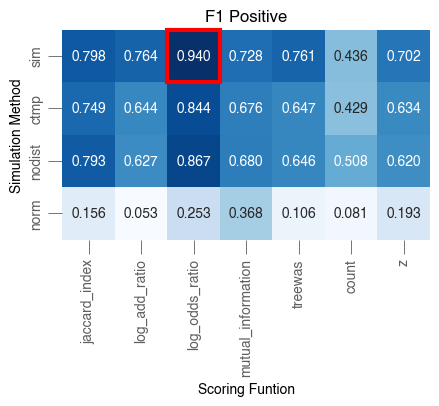

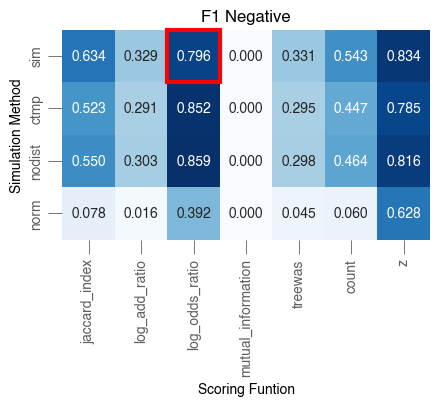

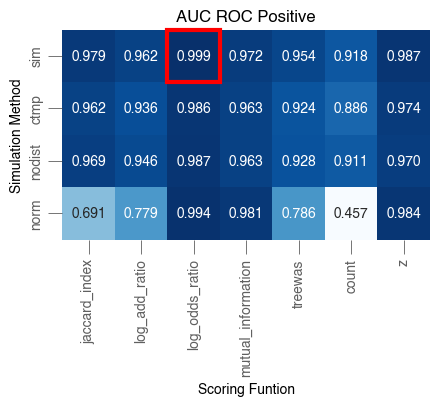

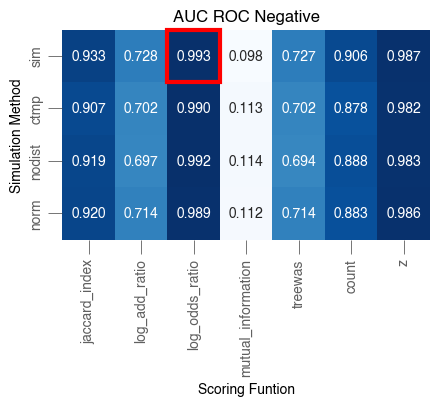

In [9]:
plot_trav(pt_concat, "Precision_Positive", 1)
plot_trav(pt_concat, "Recall_Positive", 1)
plot_trav(pt_concat, "Precision_Negative", 1)
plot_trav(pt_concat, "Recall_Negative", 1)
plot_trav(pt_concat,'F1_Positive', 1)
plot_trav(pt_concat,"F1_Negative", 1)
plot_trav(pt_concat,'AUC_ROC_Positive', 1)
plot_trav(pt_concat,"AUC_ROC_Negative", 1)



/var/folders/qm/d37lnvhs7cd5kpd230vrrdp80000gn/T/ipykernel_15965/3003533327.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_stars = matrix_pval.applymap(p_to_stars)
/var/folders/qm/d37lnvhs7cd5kpd230vrrdp80000gn/T/ipykernel_15965/3003533327.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_stars = matrix_pval.applymap(p_to_stars)
/var/folders/qm/d37lnvhs7cd5kpd230vrrdp80000gn/T/ipykernel_15965/3003533327.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_stars = matrix_pval.applymap(p_to_stars)
/var/folders/qm/d37lnvhs7cd5kpd230vrrdp80000gn/T/ipykernel_15965/3003533327.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_stars = matrix_pval.applymap(p_to_stars)


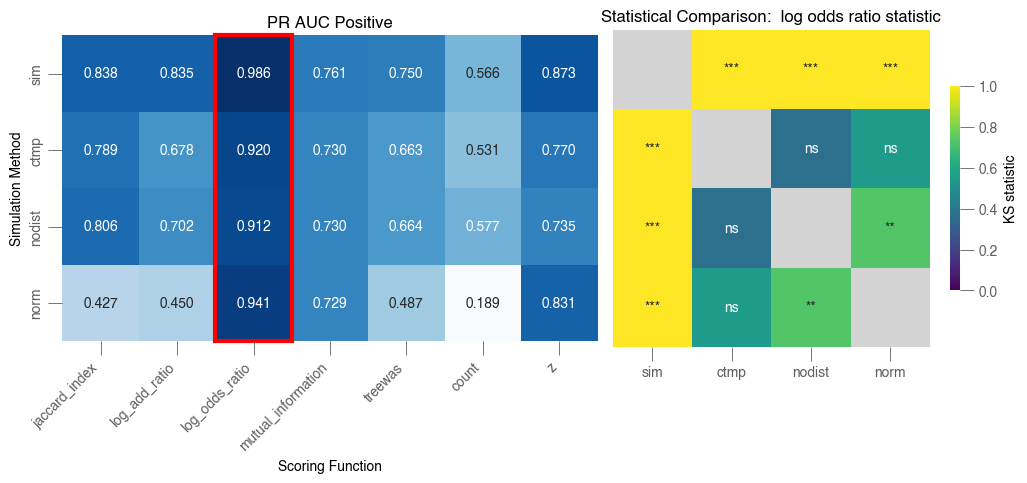

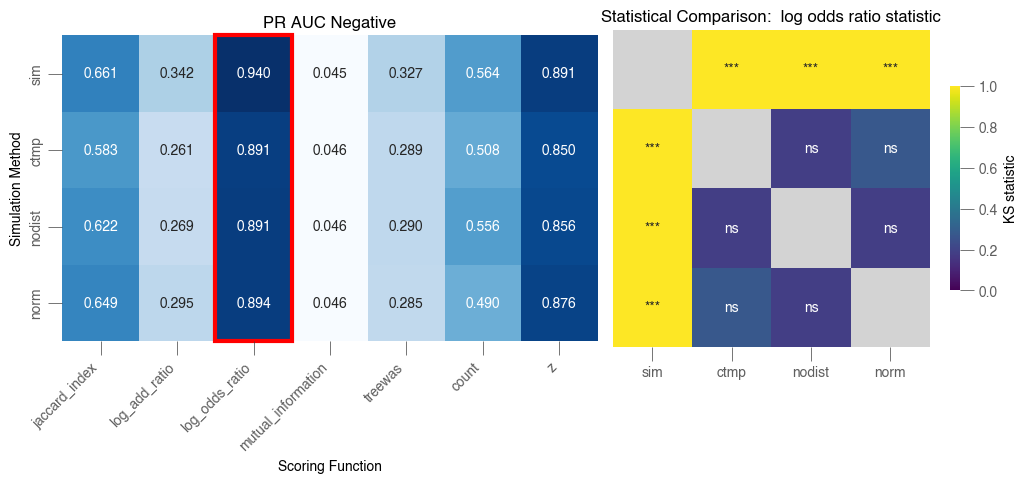

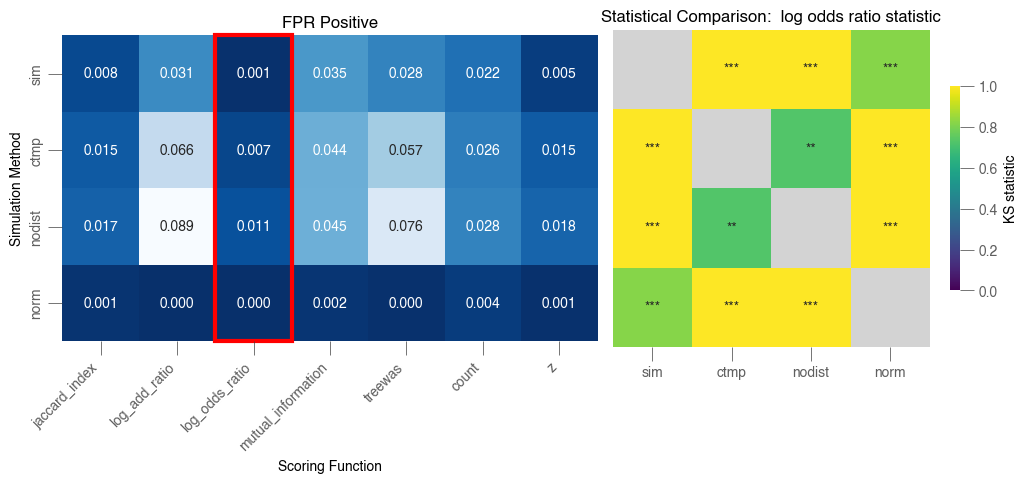

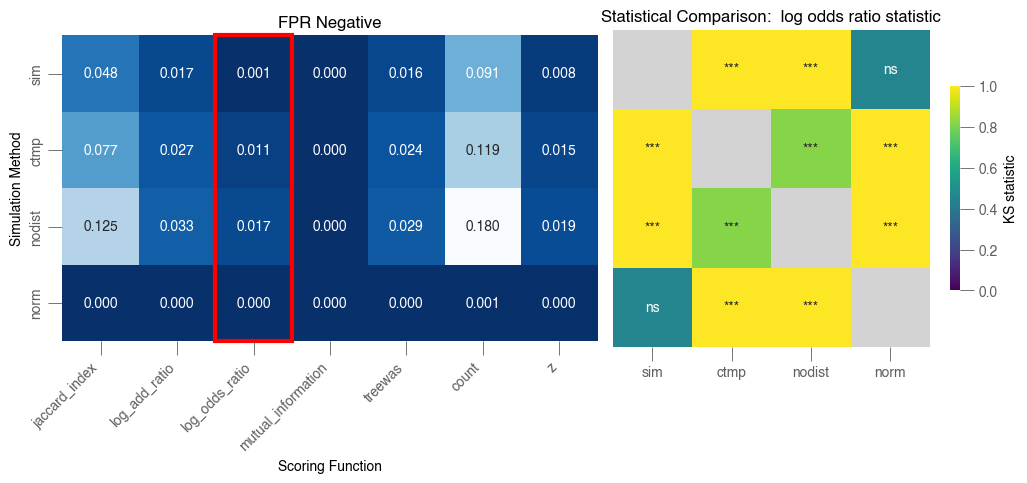

In [10]:
def plot_trav_and_ks(pt_concat, metric, pow, stat_name="_log_odds_ratio_statistic", ascending=True):

    # ---- LEFT PANEL: traversal pivot ----
    piv = pd.pivot_table(
        pt_concat[pt_concat['Power'] == pow],
        index='Method', columns='Statistic', values=metric
    )

    def rename_method(orig):
        return 'sim' if orig == 'simulate' else orig[9:]
    
    piv.index = [rename_method(i) for i in piv.index]
    piv.columns = [i[1:-10] if i.startswith('_') else i[:-10] for i in piv.columns]

    method_order = list(piv.index)
    n = len(method_order)

    stat_name_col = stat_name[1:-10] if stat_name.startswith('_') else stat_name[:-10]

    # ---- Compute KS statistics, writing into matrix that follows `method_order` ----
    df_stat = pt_concat[(pt_concat["Statistic"] == stat_name) & (pt_concat["Power"] == pow)]

    # initialize matrices indexed by traversal-method labels
    matrix_stat = pd.DataFrame(np.nan, index=method_order, columns=method_order)
    matrix_pval = pd.DataFrame(np.nan, index=method_order, columns=method_order)

    # compute pairwise KS for original method names but place results into renamed slots
    unique_orig_methods = sorted(df_stat["Method"].unique())
    for m1, m2 in itertools.combinations(unique_orig_methods, 2):
        # compute KS on the metric values
        stat, pval = ks_2samp(
            df_stat.loc[df_stat["Method"] == m1, metric],
            df_stat.loc[df_stat["Method"] == m2, metric]
        )

        lm1 = rename_method(m1)
        lm2 = rename_method(m2)

        # place into both symmetric positions using traversal ordering
        if lm1 in matrix_stat.index and lm2 in matrix_stat.columns:
            matrix_stat.loc[lm1, lm2] = stat
            matrix_stat.loc[lm2, lm1] = stat
            matrix_pval.loc[lm1, lm2] = pval
            matrix_pval.loc[lm2, lm1] = pval
        else:
            pass

    # diagonal remains NaN and will be greyed out visually
    mask = np.eye(n, dtype=bool)

    # significance stars
    def p_to_stars(p):
        if pd.isnull(p):
            return ""
        if p < 0.001:
            return "***"
        if p < 0.01:
            return "**"
        if p < 0.05:
            return "*"
        return "ns"

    annot_stars = matrix_pval.applymap(p_to_stars)

    # ---- Create side-by-side figure ----
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5),
                             gridspec_kw={"width_ratios": [1.35, 1]})

    # LEFT: traversal heatmap
    ax0 = axes[0]
    sns.heatmap(piv, cmap='Blues' if ascending else 'Blues_r',
                annot=True, fmt=".3f", cbar=False, square=True, ax=ax0)
    ax0.set_ylabel("Simulation Method")
    ax0.set_xlabel("Scoring Function")
    ax0.set_title(metric.replace('_', ' '))
    ax0.set_xticklabels(ax0.get_xticklabels(), rotation=45, ha='right')

    # Draw red box around the column for stat_name if present
    if stat_name_col in list(piv.columns):
        col_idx = list(piv.columns).index(stat_name_col)
        ax0.add_patch(plt.Rectangle((col_idx, 0), 1, piv.shape[0],
                                    fill=False, lw=3, edgecolor='red', clip_on=False))

    # RIGHT: KS heatmap — uses same ordering as traversal pivot
    ax1 = axes[1]
    sns.heatmap(matrix_stat.astype(float),
                cmap=sns.color_palette("viridis", as_cmap=True),
                annot=annot_stars, fmt="",
                square=True, ax=ax1,
                cbar_kws={"label": "KS statistic", "shrink": 0.6},
                vmin=0, vmax=1,
                mask=mask, linewidths=0)

    # grey diagonal overlay
    for i in range(n):
        ax1.add_patch(plt.Rectangle((i, i), 1, 1, color="lightgrey", fill=True, lw=0))

    ax1.set_title(f"Statistical Comparison: {stat_name.replace('_',' ')}")

    # Remove y-axis labels from KS panel (but keep tick positions for alignment)
    ax1.set_ylabel("")
    ax1.set_yticks([])

    # rotate x labels to 45° for KS panel as well
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

    plt.tight_layout()
    return fig

pow = 0.75
x = plot_trav_and_ks(pt_concat=pt_concat,metric= "PR_AUC_Positive", pow = pow)
x = plot_trav_and_ks(pt_concat=pt_concat,metric= "PR_AUC_Negative", pow = pow)
x = plot_trav_and_ks(pt_concat=pt_concat,metric= "FPR_Positive", ascending = False, pow = pow)
x = plot_trav_and_ks(pt_concat=pt_concat,metric= "FPR_Negative", ascending = False, pow = pow)